In [1]:
import pandas as pd
import numpy as np
import joblib
import time
import tracemalloc
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              ConfusionMatrixDisplay, RocCurveDisplay)

os.makedirs('data', exist_ok=True)

# Regenerate fresh pkl files
df = pd.read_csv('../Data/group5-adult.csv')
df.replace('?', np.nan, inplace=True)
df['income'] = df['income'].str.strip()
df['income'] = (df['income'] == '>50K').astype(int)

numeric_cols     = ['age', 'fnlwgt', 'education-num',
                    'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status',
                    'occupation', 'relationship', 'race',
                    'sex', 'native-country']

X = df[numeric_cols + categorical_cols]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])
preprocessor.fit(X_train)

joblib.dump((X_train, X_test, y_train, y_test), 'data/train_test_split.pkl')
joblib.dump(preprocessor, 'data/preprocessor.pkl')

print("Data ready!")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

Data ready!
X_train: (23508, 14) | X_test: (5877, 14)


In [2]:
dt_baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

tracemalloc.start()
start = time.time()
dt_baseline.fit(X_train, y_train)
train_time = time.time() - start
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_pred = dt_baseline.predict(X_test)
y_prob = dt_baseline.predict_proba(X_test)[:, 1]

print("=" * 55)
print("DECISION TREE — BASELINE PERFORMANCE")
print("=" * 55)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Train Time: {train_time:.4f}s")
print(f"Peak Mem  : {peak / 1024:.2f} KB")
print("=" * 55)

DECISION TREE — BASELINE PERFORMANCE
Accuracy  : 0.8106
Precision : 0.6042
Recall    : 0.6123
F1 Score  : 0.6082
ROC-AUC   : 0.7428
Train Time: 0.2396s
Peak Mem  : 39343.41 KB


In [3]:
param_grid = {
    'classifier__max_depth'       : [3, 5, 10, None],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__criterion'       : ['gini', 'entropy']
}

grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_dt_pipeline = grid.best_estimator_

print(f"Best Params: {grid.best_params_}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10}


In [4]:
tracemalloc.start()
start = time.time()
best_dt_pipeline.fit(X_train, y_train)
train_time = time.time() - start
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

y_pred_best = best_dt_pipeline.predict(X_test)
y_prob_best = best_dt_pipeline.predict_proba(X_test)[:, 1]

start_pred = time.time()
_ = best_dt_pipeline.predict(X_test)
pred_time = time.time() - start_pred

print("=" * 55)
print("DECISION TREE — TUNED PERFORMANCE")
print("=" * 55)
print(classification_report(y_test, y_pred_best,
      target_names=['<=50K', '>50K']))
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_best):.4f}")
print(f"Train Time: {train_time:.4f}s")
print(f"Peak Mem  : {peak / 1024:.2f} KB")
print(f"Pred Time : {pred_time:.4f}s")
print("=" * 55)

DECISION TREE — TUNED PERFORMANCE
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.91      4466
        >50K       0.76      0.56      0.64      1411

    accuracy                           0.85      5877
   macro avg       0.81      0.75      0.77      5877
weighted avg       0.84      0.85      0.84      5877

Accuracy  : 0.8513
ROC-AUC   : 0.8985
Train Time: 0.1970s
Peak Mem  : 39341.00 KB
Pred Time : 0.0057s


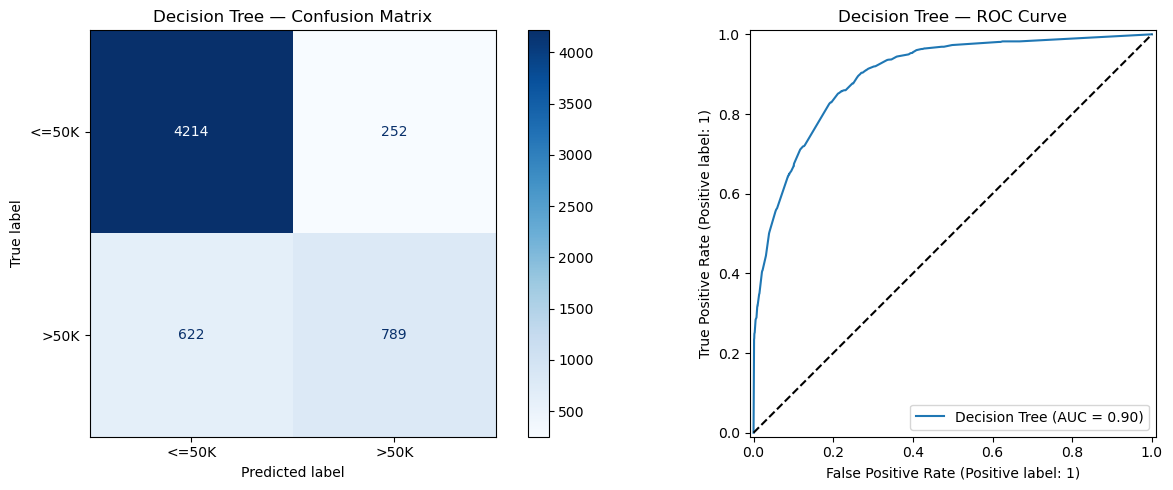

Plots saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(
    best_dt_pipeline, X_test, y_test,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Decision Tree — Confusion Matrix')

RocCurveDisplay.from_estimator(
    best_dt_pipeline, X_test, y_test,
    ax=axes[1], name='Decision Tree'
)
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('Decision Tree — ROC Curve')

plt.tight_layout()
plt.savefig('data/dt_plots.png', dpi=150)
plt.show()
print("Plots saved!")

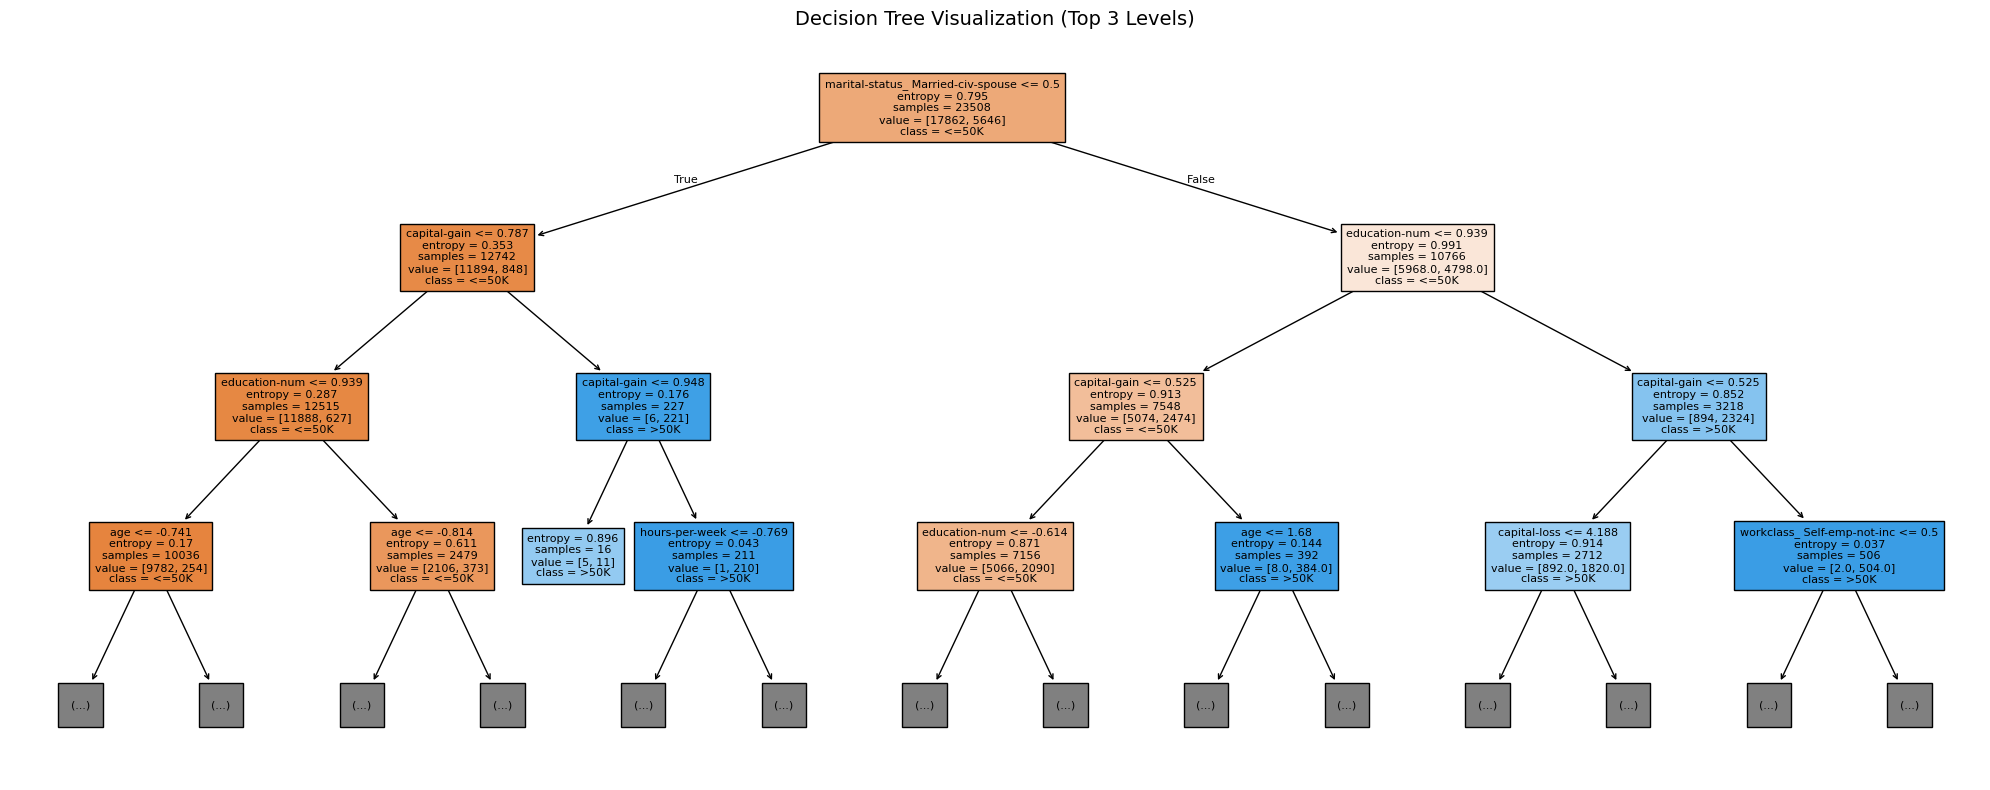

Tree visualization saved!


In [6]:
# Visualize top 3 levels of the tree
fig, ax = plt.subplots(figsize=(20, 8))

# Get feature names after encoding
feature_names = (
    numeric_cols +
    list(preprocessor.named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(categorical_cols))
)

plot_tree(
    best_dt_pipeline.named_steps['classifier'],
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    filled=True,
    max_depth=3,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree Visualization (Top 3 Levels)', fontsize=14)
plt.tight_layout()
plt.savefig('data/dt_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Tree visualization saved!")

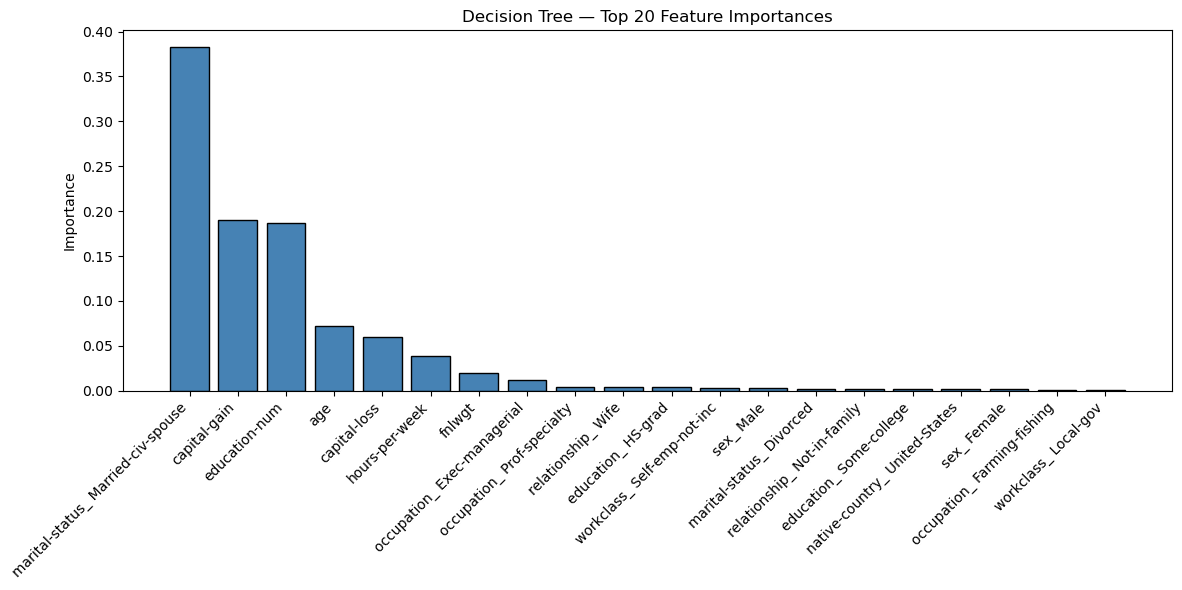

Feature importance saved!


In [7]:
importances = best_dt_pipeline.named_steps['classifier'].feature_importances_
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(20), importances[indices], color='steelblue', edgecolor='black')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
ax.set_title('Decision Tree — Top 20 Feature Importances')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('data/dt_feature_importance.png', dpi=150)
plt.show()
print("Feature importance saved!")